This notebook explores what features of a question correlate with the difficulty rating that ChatGPT assigns to it.

## Load the data
Reads the CSV. Each row is one generated question, described by ~48 columns of code and text-complexity metrics.

In [1]:
!wget https://raw.githubusercontent.com/lopezbec/Python_LLM_dificulty/refs/heads/main/code_counts.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("code_counts.csv")

# First sanity check
print("Shape:", df.shape)
print("\nFirst few rows:")
df.head()

--2026-05-04 03:15:30--  https://raw.githubusercontent.com/lopezbec/Python_LLM_dificulty/refs/heads/main/code_counts.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 69381314 (66M) [text/plain]
Saving to: ‘code_counts.csv’

code_counts.csv     100%[===================>]  66.17M   113MB/s    in 0.6s    

2026-05-04 03:15:32 (113 MB/s) - ‘code_counts.csv’ saved [69381314/69381314]

Shape: (4002, 51)

First few rows:


,hpc_folder,hpc_filename,parent_folder,parent_filename,HPC_extraction_type,set_number,method,subject,model,question_number,...,in_question_chars,elsewhere_chars,note,question_embedding,answers_embedding,mc_choices_sim_matrix,mc_choices_sim_mean,mc_choices_sim_max,mc_choices_sim_pair,mc_choices_n
0,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,10,...,7,78,NaN,"[0.03737969696521759, 0.058951400220394135, -0...","[0.0632529929280281, 0.10908082127571106, -0.0...","[[1.0000001192092896, 0.3368501663208008, 0.79...",0.4648,0.7903,"[0, 2]",3
1,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,1,...,0,62,NaN,"[0.010622750967741013, 0.07696312665939331, 0....","[-0.020988594740629196, 0.08703333884477615, 0...","[[1.0000003576278687, 0.9657249450683594, 0.92...",0.9517,0.9728,"[0, 3]",4
2,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,2,...,13,39,NaN,"[0.013367009349167347, 0.05568365752696991, 0....","[0.0013841724721714854, 0.024392785504460335, ...","[[1.0, 0.9893238544464111, 0.8499612808227539,...",0.8762,0.9893,"[0, 1]",4
3,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,3,...,5,27,NaN,"[0.04825473576784134, 0.12876395881175995, -0....","[0.05114741250872612, 0.12854506075382233, -0....","[[0.9999998807907104, 0.23046284914016724], [0...",0.2305,0.2305,"[0, 1]",2
4,JSON_individualQs_HPC_done,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,NaN,set_10_drag-and-drop_If-Statements_gpt-4o-mini...,LLM,10,drag-and-drop,If-Statements,gpt-4o-mini,4,...,28,118,NaN,"[0.025255111977458, 0.016033248975872993, -0.0...","[0.022638650611042976, 0.054916393011808395, -...","[[1.0, 0.5360086560249329, 0.6038275957107544,...",0.6877,0.9725,"[0, 3]",4


## Plot styling and a fixed model order
Sets a consistent visual style for all plots and locks in the order models appear in (smaller → larger within each family). Using a fixed order across every chart makes comparisons readable.

In [2]:
# Make plots look nicer by default
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

# Define a consistent model order for all plots
MODEL_ORDER = ["gpt-4o-mini", "gpt-4o", "o1-mini", "o1", "o3-mini"]

print("Setup complete.")

Setup complete.


## Sanity-check the experimental design
Counts rows by model, method, subject, and extraction type. We expect ~800 questions per model (5 × 800 ≈ 4,000) and balanced coverage across methods and subjects.

In [3]:
# How many of each kind?
print("=== ROWS PER MODEL ===")
print(df["model"].value_counts())

print("\n=== ROWS PER METHOD ===")
print(df["method"].value_counts())

print("\n=== ROWS PER SUBJECT ===")
print(df["subject"].value_counts())

print("\n=== EXTRACTION TYPE ===")
print(df["HPC_extraction_type"].value_counts(dropna=False))

print("\n=== DIFFICULTY RANGE (question_number) ===")
print(df["question_number"].describe())
print("\nValue counts:")
print(df["question_number"].value_counts().sort_index())

=== ROWS PER MODEL ===
model
o1-mini        801
o3-mini        801
gpt-4o-mini    800
gpt-4o         800
o1             800
Name: count, dtype: int64

=== ROWS PER METHOD ===
method
multiple-choice      1002
drag-and-drop        1000
fill-in-the-blank    1000
true-false           1000
Name: count, dtype: int64

=== ROWS PER SUBJECT ===
subject
Loops            2002
If-Statements    2000
Name: count, dtype: int64

=== EXTRACTION TYPE ===
HPC_extraction_type
LLM       3968
Manual      34
Name: count, dtype: int64

=== DIFFICULTY RANGE (question_number) ===
count    4002.000000
mean        5.502249
std         2.873770
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        11.000000
Name: question_number, dtype: float64

Value counts:
question_number
1     400
2     400
3     400
4     400
5     400
6     400
7     400
8     400
9     401
10    400
11      1
Name: count, dtype: int64


## Mean of every HPC complexity metric, per model
The first real comparison. Each row is a model; each column is a complexity metric measured on the HPC files (the code shown to human participants).

In [4]:
# All the HPC complexity metrics at once
hpc_metrics = [
    "hpc_snippets", "hpc_newlines", "hpc_chars", "hpc_chars_nonws",
    "hpc_pykeywords", "hpc_pykeywords_cf", "hpc_max_nesting_depth",
    "hpc_tokens", "hpc_avg_tokens_per_code_line", "hpc_operators",
    "hpc_operators_per_token_ratio", "hpc_avg_line_length", "hpc_max_line_length"
]

# Mean of each metric per model
summary = df.groupby("model")[hpc_metrics].mean().round(2)
summary = summary.reindex(MODEL_ORDER)  # use our consistent order
summary

,hpc_snippets,hpc_newlines,hpc_chars,hpc_chars_nonws,hpc_pykeywords,hpc_pykeywords_cf,hpc_max_nesting_depth,hpc_tokens,hpc_avg_tokens_per_code_line,hpc_operators,hpc_operators_per_token_ratio,hpc_avg_line_length,hpc_max_line_length
model,,,,,,,,,,,,,
gpt-4o-mini,3.06,0.13,38.26,32.58,2.92,1.07,0.05,5.66,1.52,0.0,0.0,9.29,13.57
gpt-4o,3.57,0.26,40.60,34.26,3.12,1.10,0.12,5.79,1.35,0.0,0.0,7.97,12.23
o1-mini,3.69,0.28,49.86,41.49,3.54,1.38,0.15,7.20,1.75,0.0,0.0,10.68,15.60
o1,4.13,0.23,51.70,44.13,3.86,1.29,0.08,7.19,1.71,0.0,0.0,10.57,15.36
o3-mini,3.55,0.30,42.01,34.96,3.43,1.20,0.14,6.01,1.57,0.0,0.0,9.40,13.48


## Save the summary as a CSV artifact
Saving intermediate results as CSVs.

In [5]:
summary.to_csv("model_summary_means.csv")
print("Saved.")

Saved.


## Boxplot: token count per model
Tokens here = identifier names (variables, functions). Here, a boxplot shows the full distribution per model: the box covers the middle 50% of values, the line is the median, whiskers show the typical range, dots are outliers. Reveals patterns that means hide.

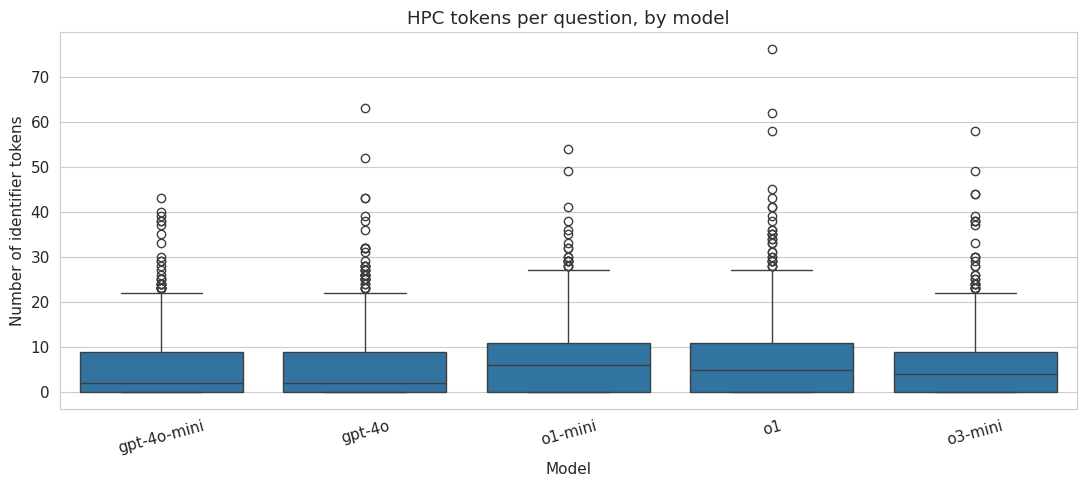

In [6]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="model", y="hpc_tokens", order=MODEL_ORDER)
plt.title("HPC tokens per question, by model")
plt.ylabel("Number of identifier tokens")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_tokens_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Boxplot: control-flow keywords per model
Counts of `if`, `for`, `while`, `try`, etc.

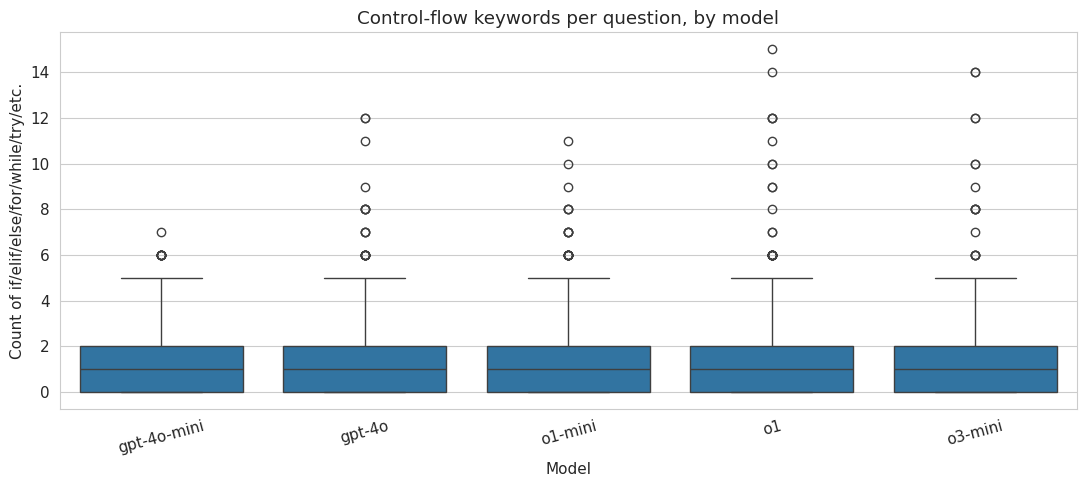

In [7]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="model", y="hpc_pykeywords_cf", order=MODEL_ORDER)
plt.title("Control-flow keywords per question, by model")
plt.ylabel("Count of if/elif/else/for/while/try/etc.")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_controlflow_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Boxplot: operator density per model
Operators per token: how arithmetic-and-logic-heavy is the code per named thing. Note: this metric will turn out to be broken in our dataset (all zeros).

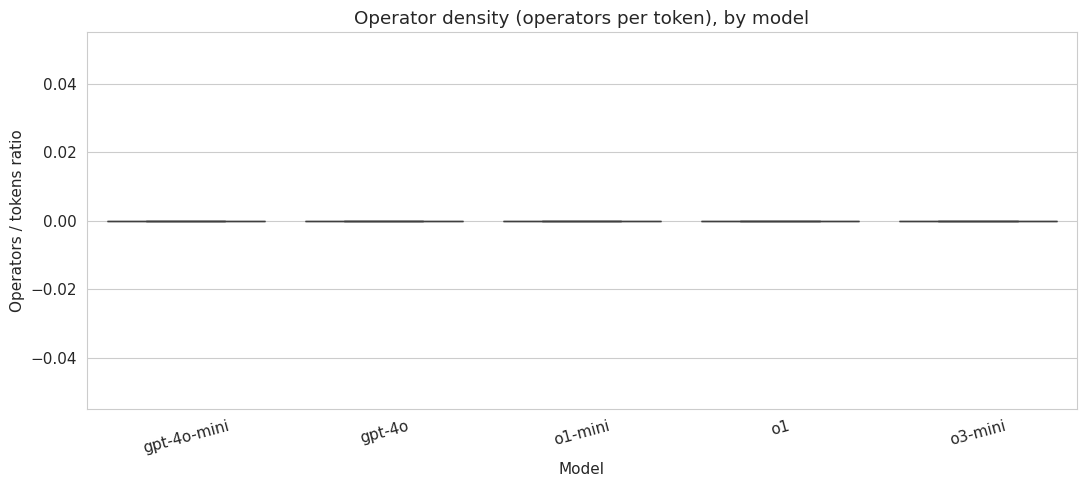

In [8]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="model", y="hpc_operators_per_token_ratio", order=MODEL_ORDER)
plt.title("Operator density (operators per token), by model")
plt.ylabel("Operators / tokens ratio")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_operator_density_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## Compute Spearman correlations across all features
For each feature, computes the rank correlation with difficulty (the `question_number` column, which is the ChatGPT-assigned difficulty rank) and a p-value (probability the correlation arose by chance). Features with too few non-null values are skipped. The resulting `corr_df` is the central result table of this phase.

In [9]:
from scipy.stats import spearmanr

# Every numeric feature we want to test
features = [
    # HPC (what humans saw)
    "hpc_snippets", "hpc_newlines", "hpc_chars", "hpc_chars_nonws",
    "hpc_pykeywords", "hpc_pykeywords_cf", "hpc_max_nesting_depth",
    "hpc_tokens", "hpc_avg_tokens_per_code_line", "hpc_operators",
    "hpc_operators_per_token_ratio", "hpc_avg_line_length", "hpc_max_line_length",
    # Parent (the original ChatGPT-generated question)
    "parent_chars", "parent_snippets", "parent_newlines",
    "parent_chars_from_snippets", "parent_chars_nonws",
    "parent_pykeywords", "parent_pykeywords_cf", "parent_max_nesting_depth",
    "parent_tokens", "parent_avg_tokens_per_code_line", "parent_operators",
    "parent_operators_per_token_ratio", "parent_avg_line_length",
    "parent_max_line_length",
    # Question structure
    "parent_answerchoices_count", "parent_answerchoices_avg_len",
    "in_question", "elsewhere", "in_question_chars", "elsewhere_chars",
    # Semantic similarity (only meaningful for MC; lots of NaN for others)
    "mc_choices_sim_mean", "mc_choices_sim_max", "mc_choices_n",
]

results = []
for feat in features:
    # Drop NaN pairs for this feature (some columns have missing values)
    pair = df[["question_number", feat]].dropna()
    if len(pair) < 30:  # too few observations to trust
        results.append({"feature": feat, "rho": None, "p_value": None, "n": len(pair)})
        continue
    rho, p = spearmanr(pair["question_number"], pair[feat])
    results.append({"feature": feat, "rho": round(rho, 3), "p_value": p, "n": len(pair)})

corr_df = pd.DataFrame(results)

/tmp/ipykernel_16450/510427334.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["question_number"], pair[feat])
/tmp/ipykernel_16450/510427334.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["question_number"], pair[feat])
/tmp/ipykernel_16450/510427334.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["question_number"], pair[feat])
/tmp/ipykernel_16450/510427334.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(pair["question_number"], pair[feat])


## Save and preview the top 10 (unsorted)
Saves the correlation table as a CSV artifact. The "top 10" preview here is just the first 10 in original order, not sorted by strength, the next cell does the proper sort.

In [10]:
corr_df.to_csv("difficulty_correlations.csv", index=False)
print("Saved difficulty_correlations.csv")
print("\nTop 10 features by correlation strength with difficulty:")
print(corr_df.head(10).to_string(index=False))

Saved difficulty_correlations.csv

Top 10 features by correlation strength with difficulty:
                     feature    rho      p_value    n
                hpc_snippets  0.104 5.249947e-11 4002
                hpc_newlines -0.015 3.532371e-01 4002
                   hpc_chars  0.177 1.236832e-29 4002
             hpc_chars_nonws  0.178 5.658394e-30 4002
              hpc_pykeywords  0.151 5.653185e-22 4002
           hpc_pykeywords_cf  0.180 2.483464e-30 4002
       hpc_max_nesting_depth -0.014 3.644680e-01 4002
                  hpc_tokens  0.197 3.179316e-36 4002
hpc_avg_tokens_per_code_line  0.165 7.478093e-26 4002
               hpc_operators    NaN          NaN 4002


## Properly rank all features by correlation strength
Sorts by absolute value of rho so the strongest correlations sit at the top, regardless of sign.

**Findings:**
- **Parent-side features dominate** the top of the ranking. The strongest correlation, `parent_chars_nonws` (ρ = 0.30), beats every HPC feature. ChatGPT's difficulty rating is more closely tied to the original question text it produced than to the extracted code shown to humans.
- **All correlations are modest**: no single feature exceeds ρ = 0.30. Difficulty is multi-causal.
- **Replicates the paper's finding**: Lopez et al. reported ρ = 0.286 for question length; we get ρ = 0.300 with a slightly cleaner length measure.

In [11]:
# Sort properly and show ALL features ranked
corr_df_sorted = corr_df.copy()
corr_df_sorted["abs_rho"] = corr_df_sorted["rho"].abs()
corr_df_sorted = corr_df_sorted.sort_values("abs_rho", ascending=False, na_position="last")

print("ALL features, ranked by correlation strength with difficulty:")
print(corr_df_sorted[["feature", "rho", "p_value", "n"]].to_string(index=False))

ALL features, ranked by correlation strength with difficulty:
                         feature    rho      p_value    n
              parent_chars_nonws  0.303 7.106649e-86 4002
      parent_chars_from_snippets  0.302 3.935271e-85 4002
                   parent_tokens  0.266 1.164588e-65 4002
          parent_max_line_length  0.252 4.804855e-59 4002
                    parent_chars  0.200 3.299146e-37 4002
                      hpc_tokens  0.197 3.179316e-36 4002
            parent_pykeywords_cf  0.195 1.527372e-35 4002
             hpc_max_line_length  0.190 7.422323e-34 4002
             hpc_avg_line_length  0.187 5.658537e-33 4002
               hpc_pykeywords_cf  0.180 2.483464e-30 4002
                 hpc_chars_nonws  0.178 5.658394e-30 4002
                       hpc_chars  0.177 1.236832e-29 4002
               in_question_chars  0.175 5.659494e-29 4002
    hpc_avg_tokens_per_code_line  0.165 7.478093e-26 4002
               parent_pykeywords  0.161 1.516652e-24 4002
          

## Diagnose the four NaN correlations
Four operator-related columns returned NaN. The diagnostic confirms they're all zero across the entire dataset. These columns should be excluded from analysis or recomputed.

In [12]:
# Why is hpc_operators NaN?
print("hpc_operators stats:")
print(df["hpc_operators"].describe())
print(f"\nUnique values: {df['hpc_operators'].nunique()}")
print(f"\nValue counts:")
print(df["hpc_operators"].value_counts().head())

hpc_operators stats:
count    4002.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: hpc_operators, dtype: float64

Unique values: 1

Value counts:
hpc_operators
0    4002
Name: count, dtype: int64


## Bar chart: all correlations at a glance
Horizontal bar chart, color-coded: parent features blue, HPC features orange, others gray. The visual proof of the "parent beats HPC" finding: the top of the chart is mostly blue.

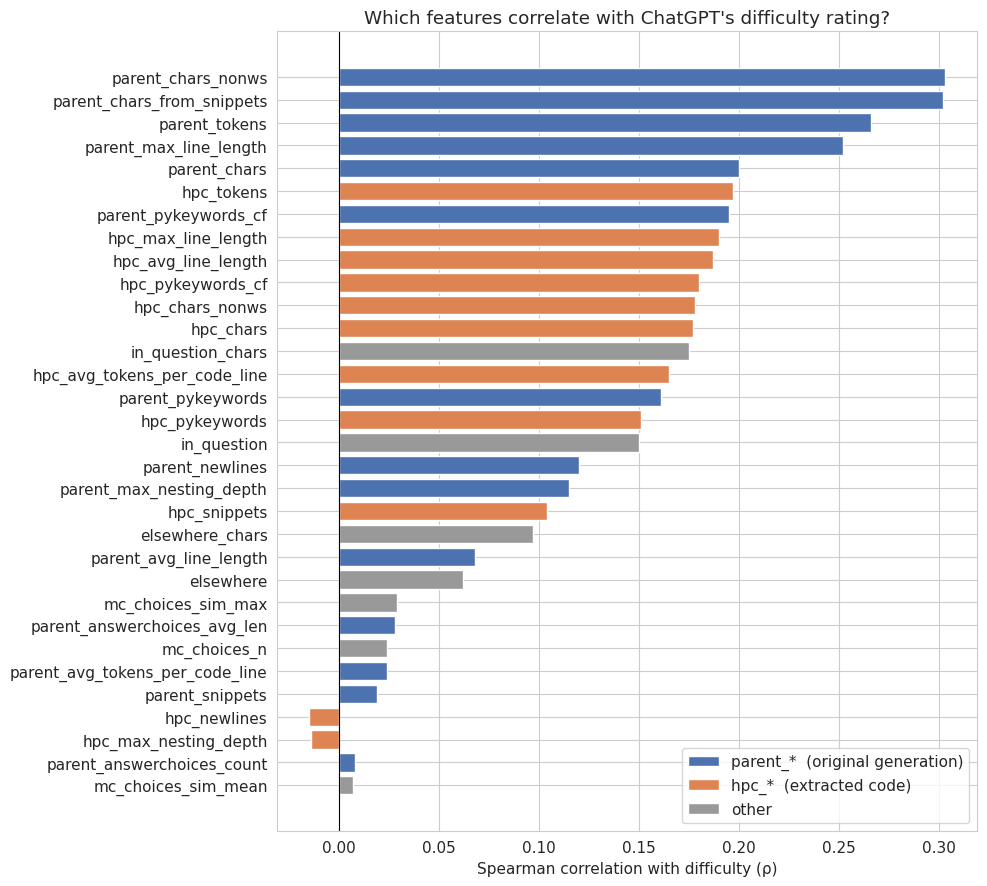

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop the dead operator columns and any rows with no rho
plot_data = corr_df_sorted.dropna(subset=["rho"]).copy()
plot_data = plot_data[~plot_data["feature"].str.contains("operator")]

# Color: parent features one color, HPC features another, others gray
def feature_color(f):
    if f.startswith("parent_"): return "#4C72B0"  # blue
    if f.startswith("hpc_"):    return "#DD8452"  # orange
    return "#999999"  # gray for the rest

colors = [feature_color(f) for f in plot_data["feature"]]

plt.figure(figsize=(10, 9))
plt.barh(plot_data["feature"], plot_data["rho"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Spearman correlation with difficulty (ρ)")
plt.title("Which features correlate with ChatGPT's difficulty rating?")
plt.gca().invert_yaxis()  # strongest at top

# Manual legend
from matplotlib.patches import Patch
legend = [Patch(facecolor="#4C72B0", label="parent_*  (original generation)"),
          Patch(facecolor="#DD8452", label="hpc_*  (extracted code)"),
          Patch(facecolor="#999999", label="other")]
plt.legend(handles=legend, loc="lower right")
plt.tight_layout()
plt.savefig("plot1_all_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Scatter plot: strongest feature vs difficulty
Shows `parent_chars_nonws` (the strongest predictor) against difficulty, with a regression line. The cloud of points is wide and noisy- that's what ρ = 0.30 actually looks like. The trend is real but explains only ~9% of the variance in difficulty.

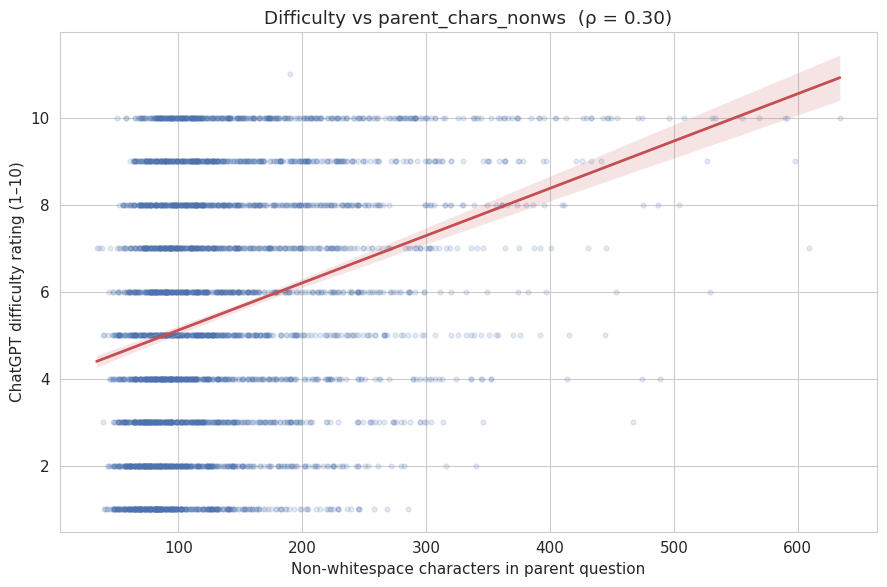

In [14]:
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df,
    x="parent_chars_nonws",
    y="question_number",
    scatter_kws={"alpha": 0.15, "s": 12, "color": "#4C72B0"},
    line_kws={"color": "#C44E52", "linewidth": 2},
)
plt.title(f"Difficulty vs parent_chars_nonws  (ρ = 0.30)")
plt.xlabel("Non-whitespace characters in parent question")
plt.ylabel("ChatGPT difficulty rating (1–10)")
plt.tight_layout()
plt.savefig("plot2_scatter_top_feature.png", dpi=150, bbox_inches="tight")
plt.show()

## Boxplot version of the same relationship
Same data, but as a boxplot. Easier to read with thousands of points: medians drift upward as difficulty increases, but the boxes overlap heavily across levels.

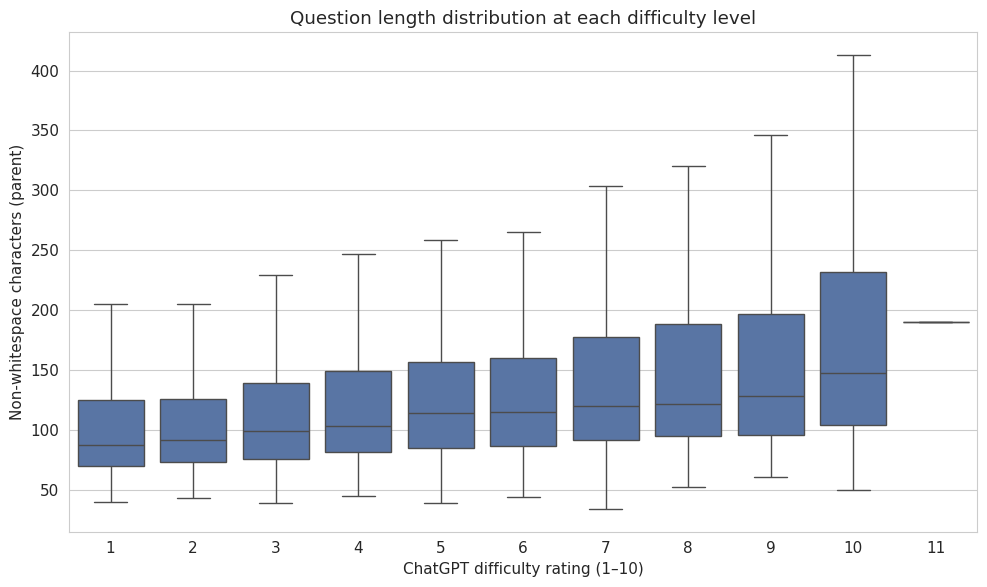

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="question_number",
    y="parent_chars_nonws",
    color="#4C72B0",
    showfliers=False,  # hide extreme outliers so boxes are readable
)
plt.title("Question length distribution at each difficulty level")
plt.xlabel("ChatGPT difficulty rating (1–10)")
plt.ylabel("Non-whitespace characters (parent)")
plt.tight_layout()
plt.savefig("plot3_boxplot_top_feature.png", dpi=150, bbox_inches="tight")
plt.show()

## Side-by-side comparison: parent vs HPC at the same metric
Visual proof of the parent-beats-HPC finding. Left panel (parent) shows a clearer upward trend than the right panel (HPC). When ChatGPT rates a question difficult, the original text length predicts it better than the extracted-code length does.

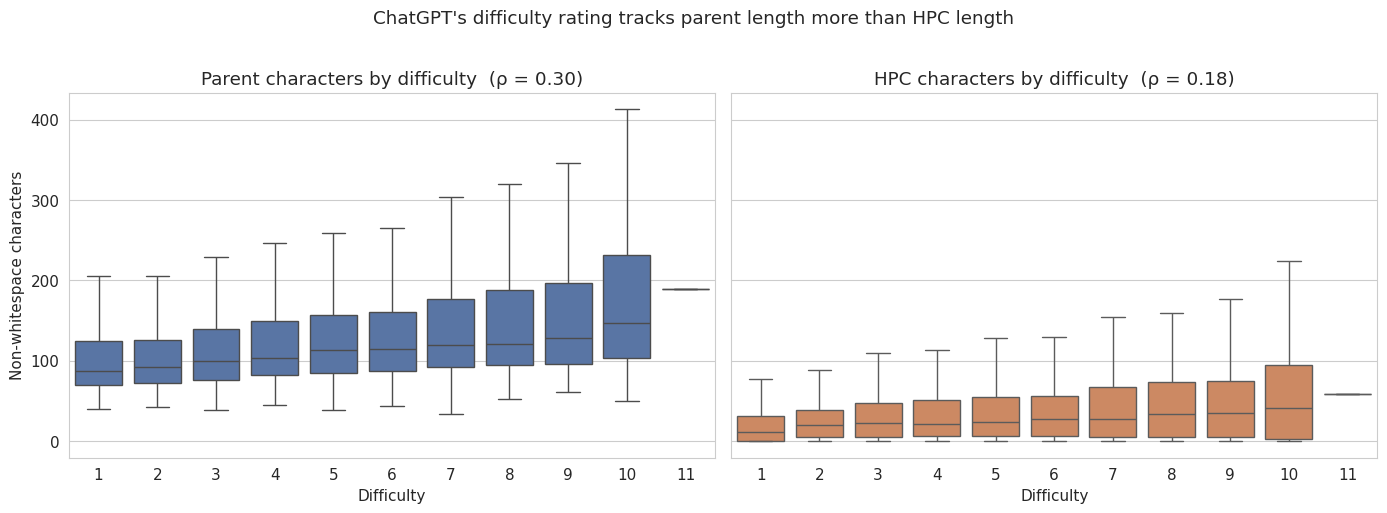

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: parent
sns.boxplot(data=df, x="question_number", y="parent_chars_nonws",
            color="#4C72B0", showfliers=False, ax=axes[0])
axes[0].set_title("Parent characters by difficulty  (ρ = 0.30)")
axes[0].set_xlabel("Difficulty")
axes[0].set_ylabel("Non-whitespace characters")

# Right: HPC
sns.boxplot(data=df, x="question_number", y="hpc_chars_nonws",
            color="#DD8452", showfliers=False, ax=axes[1])
axes[1].set_title("HPC characters by difficulty  (ρ = 0.18)")
axes[1].set_xlabel("Difficulty")
axes[1].set_ylabel("")

plt.suptitle("ChatGPT's difficulty rating tracks parent length more than HPC length", y=1.02)
plt.tight_layout()
plt.savefig("plot4_parent_vs_hpc.png", dpi=150, bbox_inches="tight")
plt.show()

## Spearman correlations split by model
For each (feature, model) pair, computes the correlation. Result is a feature × model table: the heart of the model-comparison analysis.

In [17]:
from scipy.stats import spearmanr

# Subset of features worth comparing — top performers + a few interesting nulls
key_features = [
    "parent_chars_nonws", "parent_tokens", "parent_max_line_length",
    "parent_pykeywords_cf", "hpc_tokens", "hpc_pykeywords_cf",
    "hpc_max_nesting_depth", "parent_max_nesting_depth",
    "mc_choices_sim_max", "parent_answerchoices_avg_len",
]

# Build a table: rows = features, columns = models, values = Spearman rho
per_model = {}
for model in MODEL_ORDER:
    sub = df[df["model"] == model]
    rhos = {}
    for feat in key_features:
        pair = sub[["question_number", feat]].dropna()
        if len(pair) < 30:
            rhos[feat] = None
            continue
        rho, _ = spearmanr(pair["question_number"], pair[feat])
        rhos[feat] = round(rho, 3)
    per_model[model] = rhos

per_model_df = pd.DataFrame(per_model)
per_model_df = per_model_df[MODEL_ORDER]  # consistent column order

# Add a "pooled" column for reference (all models combined)
pooled = {}
for feat in key_features:
    pair = df[["question_number", feat]].dropna()
    rho, _ = spearmanr(pair["question_number"], pair[feat])
    pooled[feat] = round(rho, 3)
per_model_df["POOLED"] = pd.Series(pooled)

per_model_df

,gpt-4o-mini,gpt-4o,o1-mini,o1,o3-mini,POOLED
parent_chars_nonws,0.269,0.342,0.326,0.278,0.365,0.303
parent_tokens,0.233,0.291,0.291,0.237,0.342,0.266
parent_max_line_length,0.235,0.287,0.256,0.258,0.299,0.252
parent_pykeywords_cf,0.133,0.247,0.184,0.171,0.256,0.195
hpc_tokens,0.143,0.172,0.226,0.205,0.252,0.197
hpc_pykeywords_cf,0.126,0.182,0.177,0.183,0.231,0.180
hpc_max_nesting_depth,-0.034,-0.056,-0.001,0.016,0.004,-0.014
parent_max_nesting_depth,0.075,0.106,0.157,0.096,0.155,0.115
mc_choices_sim_max,-0.008,0.017,0.026,0.050,0.052,0.029
parent_answerchoices_avg_len,0.013,0.030,0.032,0.045,0.018,0.028


## Heatmap of per-model correlations
Visualizes the table from the previous cell. Rows uniformly red across all columns = features every model relies on. Mixed-color rows = features where models disagree.

**Finding:** All models broadly agree on direction: no row goes positive for some models and negative for others. But magnitudes vary systematically. o3-mini's difficulty ratings correlate most strongly with surface features (top of the heatmap is darkest red on its column); gpt-4o-mini's correlations are consistently weakest. Two interpretations: (a) o3-mini ties difficulty more reliably to measurable code/text complexity, (b) gpt-4o-mini relies on features not captured in this dataset.

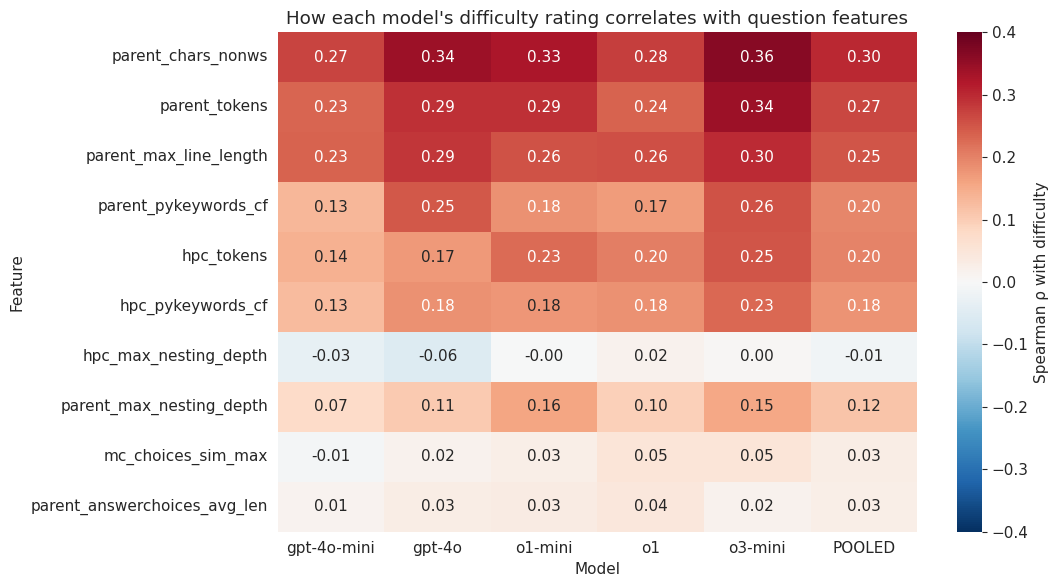

In [18]:
plt.figure(figsize=(11, 6))
sns.heatmap(
    per_model_df.astype(float),
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4,
    cbar_kws={"label": "Spearman ρ with difficulty"}
)
plt.title("How each model's difficulty rating correlates with question features")
plt.xlabel("Model")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plot5_per_model_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Note on values vs. earlier run:** A handful of cells differ from the previous version of this heatmap by 0.01–0.02. This is expected: the earlier run pulled difficulty from the JSON files and dropped 121 rows where the field was missing (101 o1-mini, 20 gpt-4o). The current run uses `question_number` from the CSV, which is populated for every row, so those 121 rows are back in the sample. The shifts appear almost exclusively in the o1-mini and gpt-4o columns (and POOLED) — the three other models had no missing labels and their values are unchanged. The qualitative findings hold.

# **Feature-to-feature corerelation**

Before running multivariate regression, we need to know which features are redundant. Throwing 28+ features into an OLS model where many are essentially measuring the same thing (e.g., line count and character count) inflates standard errors, makes coefficients unstable, and breaks AIC/BIC selection. This section finds the redundancy clusters and produces a lean feature list ready for regression.

## Build the analysis-ready feature list
Pulls together every numeric complexity feature we want to test for redundancy. Drops the four operator columns (broken, all zeros) and keeps `question_number` separate so we can use it as the difficulty target when choosing representatives later. Also prints a NaN summary so we know which features have missingness issues before we trust the correlation matrix.

In [19]:
# Features to test for redundancy (drops the four broken operator columns)
analysis_features = [
    # HPC code metrics
    "hpc_snippets", "hpc_newlines", "hpc_chars", "hpc_chars_nonws",
    "hpc_pykeywords", "hpc_pykeywords_cf", "hpc_max_nesting_depth",
    "hpc_tokens", "hpc_avg_tokens_per_code_line",
    "hpc_avg_line_length", "hpc_max_line_length",
    # Parent metrics
    "parent_chars", "parent_snippets", "parent_newlines",
    "parent_chars_from_snippets", "parent_chars_nonws",
    "parent_pykeywords", "parent_pykeywords_cf", "parent_max_nesting_depth",
    "parent_tokens", "parent_avg_tokens_per_code_line",
    "parent_avg_line_length", "parent_max_line_length",
    # Question structure
    "parent_answerchoices_count", "parent_answerchoices_avg_len",
    "in_question", "elsewhere", "in_question_chars", "elsewhere_chars",
]

print(f"Total features to test: {len(analysis_features)}")

nan_summary = df[analysis_features].isna().sum().sort_values(ascending=False)
nan_with_data = nan_summary[nan_summary > 0]

print(f"\nNaN counts per feature:")
if len(nan_with_data):
    print(nan_with_data.to_string())
else:
    print("(no NaNs in any analysis feature)")

print(f"\nRows with at least one NaN across analysis features: "
      f"{df[analysis_features].isna().any(axis=1).sum()} of {len(df)}")

Total features to test: 29

NaN counts per feature:
(no NaNs in any analysis feature)

Rows with at least one NaN across analysis features: 0 of 4002


## Compute the feature-to-feature Spearman correlation matrix
Spearman because the same logic from the difficulty correlations applies here: many features are bounded at zero, distributions are skewed, and we care about monotonic relationships rather than strictly linear ones. Includes `question_number` as the first row/column so we can see each feature's relationship to difficulty alongside its relationship to other features. Pandas `.corr` handles NaN pairwise.

In [20]:
# Include question_number so we can see each feature's relationship to difficulty
# alongside its relationship to other features
matrix_cols = ["question_number"] + analysis_features
corr_matrix = df[matrix_cols].corr(method="spearman")

# Save the raw matrix
corr_matrix.to_csv("feature_feature_spearman.csv")
print(f"Matrix shape: {corr_matrix.shape}")
print(f"Saved feature_feature_spearman.csv")
print(f"\nDiagonal sanity check (should all be 1.00): {corr_matrix.values.diagonal()[:5]}...")

Matrix shape: (30, 30)
Saved feature_feature_spearman.csv

Diagonal sanity check (should all be 1.00): [1. 1. 1. 1. 1.]...


## Heatmap: features ordered by category
The basic visual. Features are grouped by source (parent vs HPC vs structure) so you can see where redundancy clusters live. Top row and left column = correlation with `question_number` (the difficulty target). Inside the matrix, dark red = highly correlated pair (likely redundant); dark blue = strongly inversely correlated; near-white = independent.

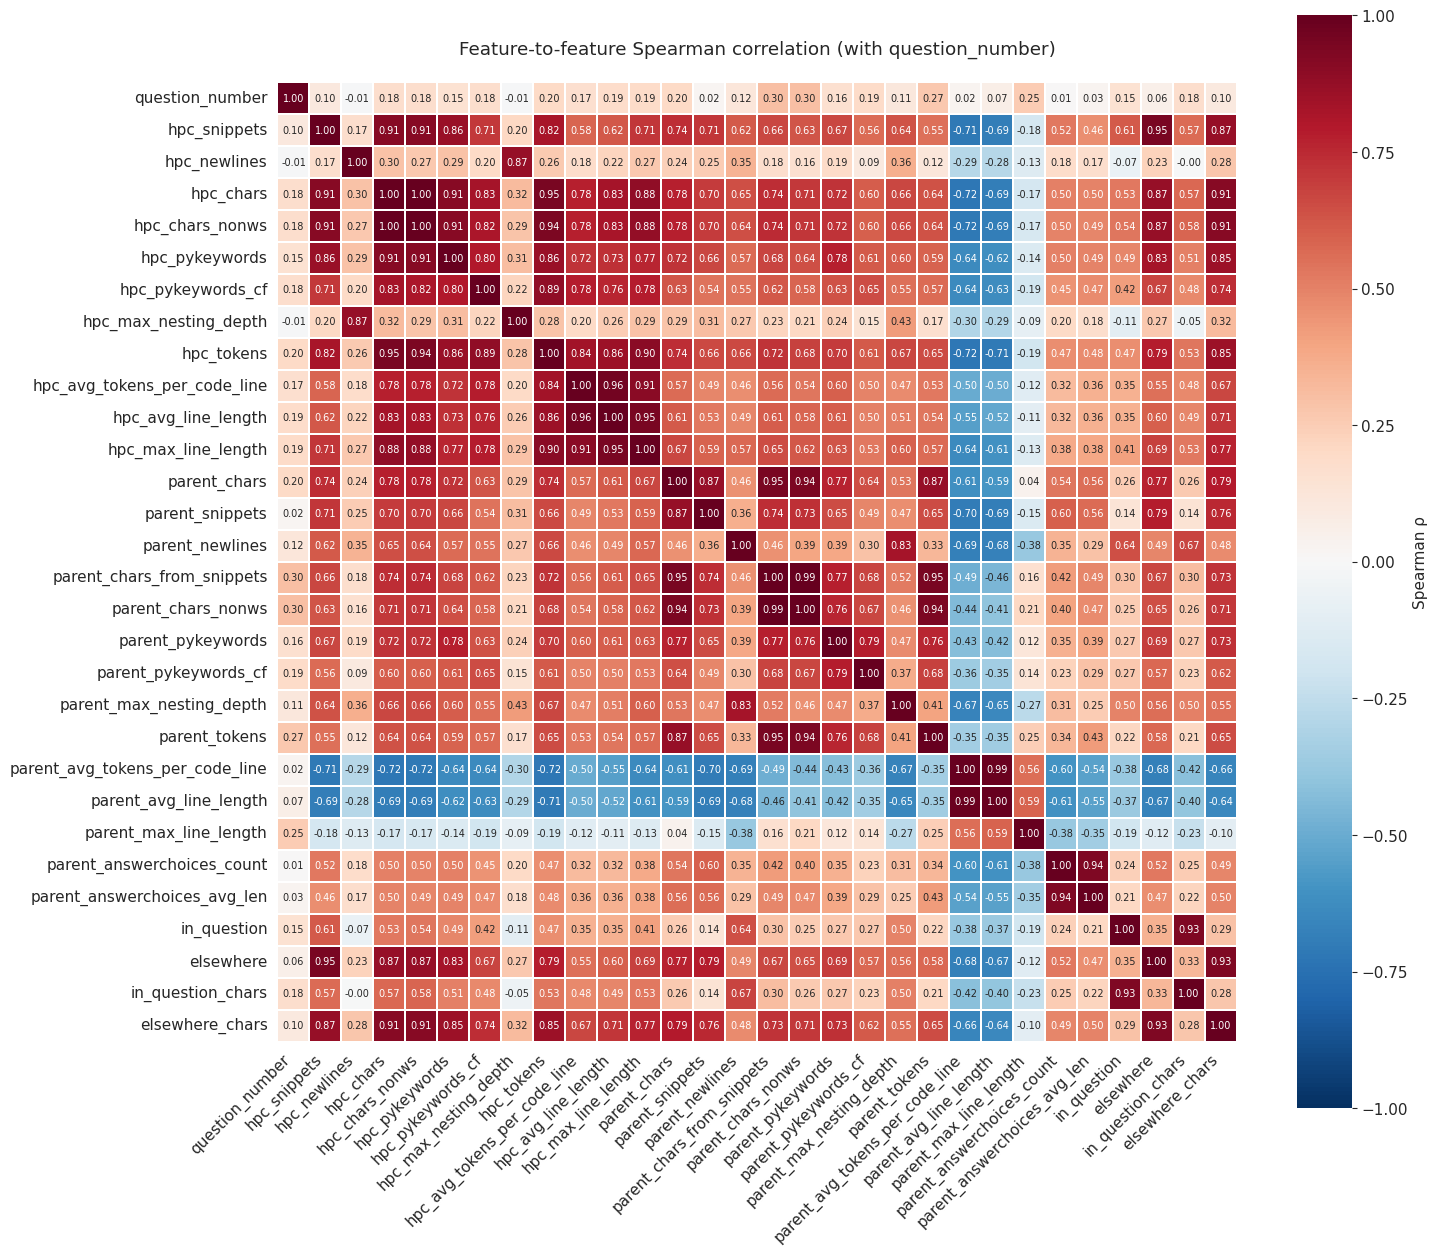

In [21]:
plt.figure(figsize=(15, 13))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot_kws={"size": 7},
    cbar_kws={"label": "Spearman ρ"},
    square=True,
    linewidths=0.3,
    linecolor="white",
)
plt.title("Feature-to-feature Spearman correlation (with question_number)", pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("plot_feature_heatmap_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

## Clustermap: hierarchical clustering reveals redundancy blocks
Same data as the previous heatmap, but rows and columns are reordered by hierarchical clustering on `1 - |ρ|` distance. Highly correlated features end up adjacent, so redundancy shows up as block-diagonal structure. The dendrograms on the top and left show how features group together at different similarity thresholds. This is the main visual deliverable of this section.

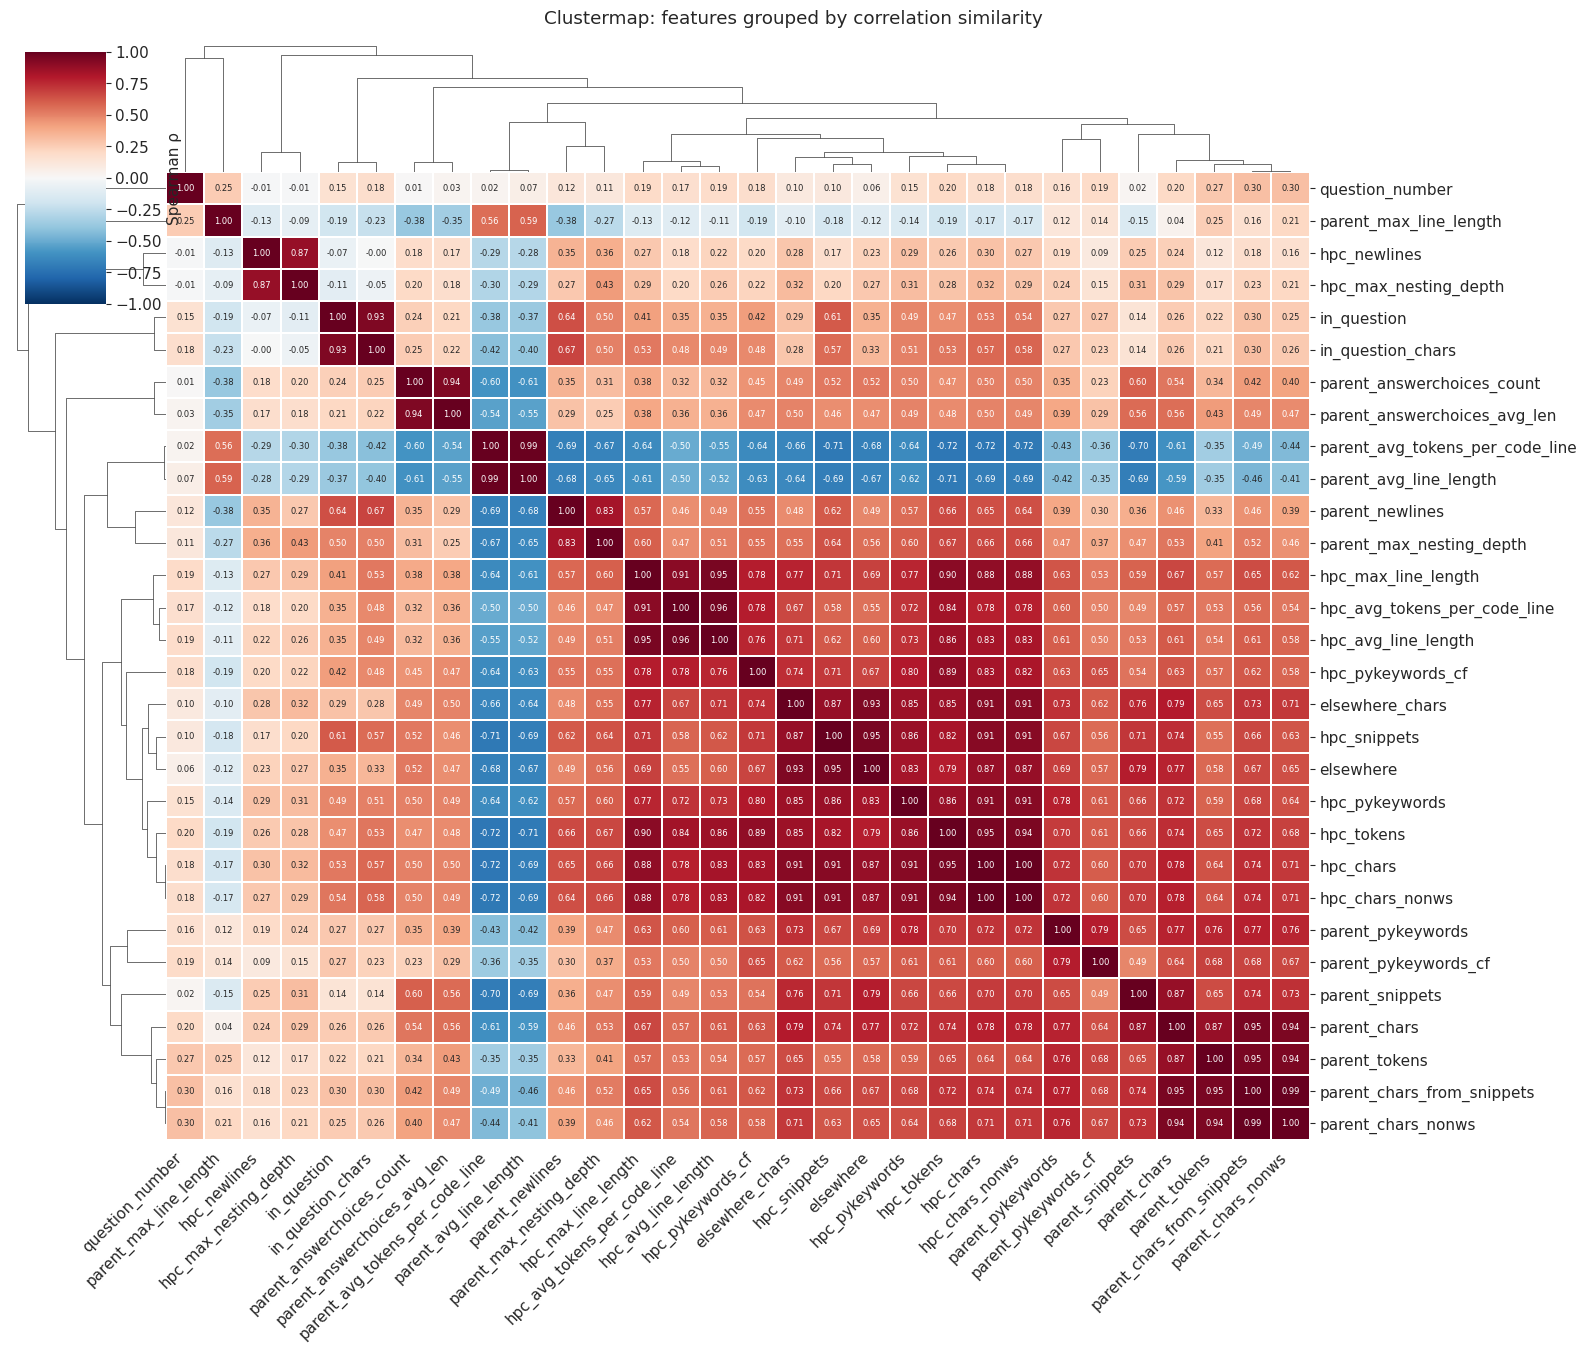

In [22]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

# Distance = 1 - |ρ|. Two perfectly correlated features have distance 0; uncorrelated have distance 1.
dist_matrix = 1 - corr_matrix.abs()
np.fill_diagonal(dist_matrix.values, 0)  # ensure exact zero on diagonal

# Convert to condensed form for scipy
condensed = squareform(dist_matrix.values, checks=False)
row_linkage = linkage(condensed, method="average")

g = sns.clustermap(
    corr_matrix,
    row_linkage=row_linkage,
    col_linkage=row_linkage,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    annot_kws={"size": 6},
    figsize=(16, 14),
    cbar_kws={"label": "Spearman ρ"},
    dendrogram_ratio=0.12,
    linewidths=0.2,
    linecolor="white",
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right")
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.fig.suptitle("Clustermap: features grouped by correlation similarity", y=1.01)
plt.savefig("plot_feature_clustermap.png", dpi=150, bbox_inches="tight")
plt.show()

## List highly correlated feature pairs
The concrete output: every pair of features with |ρ| above 0.8, sorted by strength. These are your strongest redundancy candidates. A pair at ρ = 0.95 means the two features are essentially measuring the same thing; including both in a regression adds noise without information.

In [23]:
# Pull just the feature-feature block (drop question_number)
ff_corr = corr_matrix.drop("question_number", axis=0).drop("question_number", axis=1)

# Get upper triangle as a Series of (feat1, feat2) -> rho
mask = np.triu(np.ones(ff_corr.shape, dtype=bool), k=1)
upper = ff_corr.where(mask)
pairs = upper.stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "rho"]
pairs["abs_rho"] = pairs["rho"].abs()
pairs = pairs.sort_values("abs_rho", ascending=False).reset_index(drop=True)

# Threshold for "redundant"
THRESHOLD = 0.8
redundant = pairs[pairs["abs_rho"] >= THRESHOLD]

print(f"Total feature pairs: {len(pairs)}")
print(f"Pairs with |ρ| ≥ {THRESHOLD}: {len(redundant)}")

print(f"\nTop 20 most correlated pairs:")
print(pairs.head(20)[["feature_1", "feature_2", "rho"]].to_string(index=False))

print(f"\nAll redundancy candidates (|ρ| ≥ {THRESHOLD}):")
print(redundant[["feature_1", "feature_2", "rho"]].to_string(index=False))

redundant.to_csv("feature_redundancy_pairs.csv", index=False)
print(f"\nSaved feature_redundancy_pairs.csv")

Total feature pairs: 406
Pairs with |ρ| ≥ 0.8: 45

Top 20 most correlated pairs:
                      feature_1                    feature_2      rho
                      hpc_chars              hpc_chars_nonws 0.997589
     parent_chars_from_snippets           parent_chars_nonws 0.992925
parent_avg_tokens_per_code_line       parent_avg_line_length 0.987301
   hpc_avg_tokens_per_code_line          hpc_avg_line_length 0.963227
            hpc_avg_line_length          hpc_max_line_length 0.950711
                      hpc_chars                   hpc_tokens 0.948478
                   parent_chars   parent_chars_from_snippets 0.947385
     parent_chars_from_snippets                parent_tokens 0.946092
                   hpc_snippets                    elsewhere 0.945410
             parent_chars_nonws                parent_tokens 0.943599
                hpc_chars_nonws                   hpc_tokens 0.943442
                   parent_chars           parent_chars_nonws 0.939973
     pare

## Sensitivity check: how does the cluster count depend on the threshold?
Before committing to |ρ| ≥ 0.8 as the redundancy cutoff, sweep through a range of thresholds and see how many clusters fall out at each. This is a sanity check: if the cluster count is wildly sensitive (e.g., flips from 10 to 30 between |ρ| = 0.7 and |ρ| = 0.8), the choice of threshold matters a lot. If it's stable across the range, we can be more confident in the chosen value.

 rho_threshold  n_clusters  n_features_kept
          0.50           6                6
          0.55           7                7
          0.60           7                7
          0.65           8                8
          0.70          10               10
          0.75          11               11
          0.80          14               14
          0.85          15               15
          0.90          18               18
          0.95          26               26


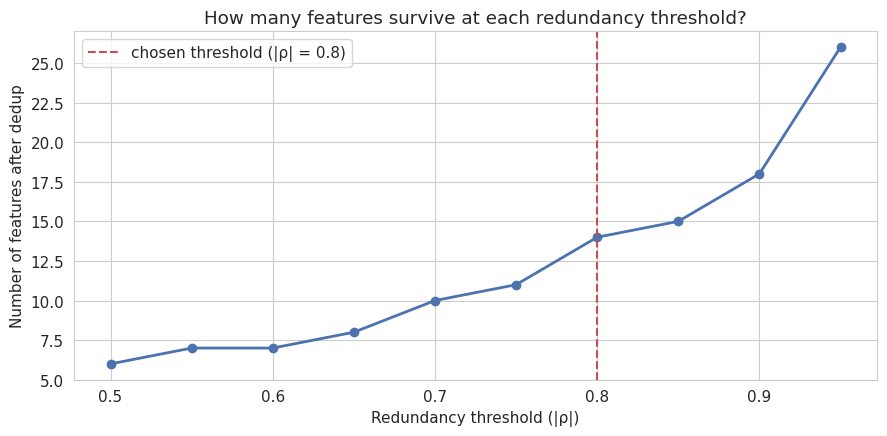

In [24]:
from scipy.cluster.hierarchy import fcluster

thresholds = np.arange(0.5, 1.0, 0.05)  # |ρ| from 0.5 to 0.95
results = []
for rho_threshold in thresholds:
    dist_threshold = 1 - rho_threshold
    cids = fcluster(row_linkage, t=dist_threshold, criterion="distance")
    results.append({
        "rho_threshold": round(rho_threshold, 2),
        "n_clusters": len(set(cids)),
        "n_features_kept": len(set(cids)),  # one rep per cluster
    })

sweep_df = pd.DataFrame(results)
print(sweep_df.to_string(index=False))

plt.figure(figsize=(9, 4.5))
plt.plot(sweep_df["rho_threshold"], sweep_df["n_features_kept"],
         marker="o", color="#4C72B0", linewidth=2)
plt.axvline(0.8, color="#C44E52", linestyle="--", linewidth=1.5,
            label="chosen threshold (|ρ| = 0.8)")
plt.xlabel("Redundancy threshold (|ρ|)")
plt.ylabel("Number of features after dedup")
plt.title("How many features survive at each redundancy threshold?")
plt.legend()
plt.tight_layout()
plt.savefig("plot_threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## Cluster features at the redundancy threshold and pick representatives
Cuts the dendrogram at distance 0.2, which corresponds to |ρ| = 0.8 in the linkage tree. Features that cluster together are treated as redundant. For each cluster, pick the single feature that correlates most strongly with `question_number`, since that's the one most useful for predicting difficulty. Singleton clusters (features with no strong twin) pass through unchanged. The result is a "lean" feature list ready for regression.

In [25]:
# Build linkage on features ONLY (exclude question_number, which is our target)
ff_dist = 1 - ff_corr.abs()
np.fill_diagonal(ff_dist.values, 0)
ff_condensed = squareform(ff_dist.values, checks=False)
ff_linkage = linkage(ff_condensed, method="average")

# Cut the dendrogram at distance threshold (|ρ| = 0.8 → distance = 0.2)
DIST_THRESHOLD = 0.2
cluster_ids = fcluster(ff_linkage, t=DIST_THRESHOLD, criterion="distance")

# Map each feature to its cluster ID
feature_clusters = pd.DataFrame({
    "feature": ff_corr.index,
    "cluster": cluster_ids,
})

# For ranking: each feature's |correlation with question_number|
diff_corr = corr_matrix["question_number"].drop("question_number").abs()
feature_clusters["abs_rho_with_difficulty"] = (
    feature_clusters["feature"].map(diff_corr).round(3)
)

# For each cluster, pick the feature with the strongest difficulty correlation
representatives = (
    feature_clusters
    .sort_values("abs_rho_with_difficulty", ascending=False)
    .groupby("cluster", as_index=False)
    .first()
)

print(f"Number of clusters at distance {DIST_THRESHOLD} (|ρ| ≥ {1 - DIST_THRESHOLD:.1f}): "
      f"{feature_clusters['cluster'].nunique()}")
print(f"Original feature count: {len(feature_clusters)}")
print(f"Lean feature count after dedup: {len(representatives)}")

print(f"\nClusters and their representatives:")
print("=" * 80)
for cid in sorted(feature_clusters["cluster"].unique()):
    members = feature_clusters[feature_clusters["cluster"] == cid].sort_values(
        "abs_rho_with_difficulty", ascending=False
    )
    rep = representatives[representatives["cluster"] == cid].iloc[0]["feature"]
    if len(members) == 1:
        print(f"  Cluster {cid:>2}: {members.iloc[0]['feature']} (singleton)")
    else:
        print(f"  Cluster {cid:>2}: representative = {rep}")
        for _, m in members.iterrows():
            marker = "  ← keep" if m["feature"] == rep else "    drop"
            print(f"          {m['feature']:40s}  ρ_diff = {m['abs_rho_with_difficulty']:.3f}{marker}")
print("=" * 80)

lean_features = sorted(representatives["feature"].tolist())
print(f"\nLean feature list ({len(lean_features)} features):")
for f in lean_features:
    print(f"  {f}")

Number of clusters at distance 0.2 (|ρ| ≥ 0.8): 13
Original feature count: 29
Lean feature count after dedup: 13

Clusters and their representatives:
  Cluster  1: representative = hpc_newlines
          hpc_newlines                              ρ_diff = 0.015  ← keep
          hpc_max_nesting_depth                     ρ_diff = 0.014    drop
  Cluster  2: representative = in_question_chars
          in_question_chars                         ρ_diff = 0.175  ← keep
          in_question                               ρ_diff = 0.150    drop
  Cluster  3: representative = parent_answerchoices_avg_len
          parent_answerchoices_avg_len              ρ_diff = 0.028  ← keep
          parent_answerchoices_count                ρ_diff = 0.008    drop
  Cluster  4: representative = parent_avg_line_length
          parent_avg_line_length                    ρ_diff = 0.068  ← keep
          parent_avg_tokens_per_code_line           ρ_diff = 0.024    drop
  Cluster  5: representative = parent_newli

## Variance Inflation Factor (VIF) on the lean feature list
A second-pass multicollinearity check. The clustering catches pairwise redundancy, but a feature can still be a near-perfect linear combination of three or four others without any individual pair being above the threshold. VIF measures exactly that. Rule of thumb: VIF < 5 is fine, 5 to 10 is concerning, > 10 means the feature is essentially a linear combination of others and should be dropped before OLS.

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF needs no NaN, so drop rows where any lean feature is missing
X = df[lean_features].dropna()
print(f"Rows used for VIF (after dropna): {len(X)} of {len(df)}")

vifs = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    index=X.columns,
    name="VIF",
).sort_values(ascending=False)

print(f"\nVIF for the lean feature set:")
print(vifs.round(2).to_string())

high_vif = vifs[vifs > 5]
if len(high_vif):
    print(f"\nFeatures with VIF > 5 (potential multicollinearity):")
    print(high_vif.round(2).to_string())
    print("\nConsider dropping these (or revisiting cluster representatives) before OLS.")
else:
    print("\nAll VIFs are below 5. Feature set is regression-ready.")

Rows used for VIF (after dropna): 4002 of 4002

VIF for the lean feature set:
parent_chars_nonws              26.91
parent_max_line_length          21.93
parent_pykeywords               15.99
parent_pykeywords_cf            12.20
hpc_tokens                      11.29
parent_avg_line_length           9.56
hpc_pykeywords_cf                8.13
parent_snippets                  6.78
hpc_max_line_length              5.06
in_question_chars                4.31
parent_newlines                  3.74
parent_answerchoices_avg_len     2.40
hpc_newlines                     1.54

Features with VIF > 5 (potential multicollinearity):
parent_chars_nonws        26.91
parent_max_line_length    21.93
parent_pykeywords         15.99
parent_pykeywords_cf      12.20
hpc_tokens                11.29
parent_avg_line_length     9.56
hpc_pykeywords_cf          8.13
parent_snippets            6.78
hpc_max_line_length        5.06

Consider dropping these (or revisiting cluster representatives) before OLS.


## Save the lean feature list and the cluster mapping
Persists the deduplicated feature list as a CSV so the next phase (multivariate regression with AIC/BIC selection) can pick it up directly. Also keeps a copy of the cluster mapping in case you need to argue for a different representative later, or revisit the threshold.

In [27]:
# Save the lean feature list
pd.Series(lean_features, name="feature").to_csv("regression_features_lean.csv", index=False)

# Save the full cluster mapping (which features were grouped together, which got picked)
cluster_mapping = feature_clusters.copy()
cluster_mapping["is_representative"] = cluster_mapping["feature"].isin(lean_features)
cluster_mapping = cluster_mapping.sort_values(
    ["cluster", "abs_rho_with_difficulty"],
    ascending=[True, False],
)
cluster_mapping.to_csv("feature_cluster_mapping.csv", index=False)

print("Saved:")
print(f"  regression_features_lean.csv  ({len(lean_features)} features)")
print(f"  feature_cluster_mapping.csv  (cluster membership for all {len(feature_clusters)} original features)")

Saved:
  regression_features_lean.csv  (13 features)
  feature_cluster_mapping.csv  (cluster membership for all 29 original features)
